# Análisis Exploratorio — Prevención de Infartos

Objetivo: tomar decisiones informadas sobre limpieza, encoding y selección de características antes de pasarlas al pipeline.

**Preguntas clave:**
1. ¿Los registros con `Genero='Other'` o nulos en ciertas columnas sufrieron infarto? → ¿conviene descartarlos?
2. ¿Cuál es el mejor método de selección de características para este dataset?
3. ¿Qué modelo y qué hiperparámetros maximizan el Recall en datos tan desbalanceados?

## 0 · Configuración

Librerías, constantes globales y rutas. Ajusta `N_SPLITS` (folds de CV), `RANDOM_STATE` (semilla) y `RUTA_DATASET` si el dataset cambia de ubicación.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os, hashlib, copy
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, pointbiserialr
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB, ComplementNB
from sklearn.metrics import (
    recall_score, f1_score, roc_auc_score, precision_score,
    average_precision_score, matthews_corrcoef, balanced_accuracy_score,
    confusion_matrix, classification_report,
    precision_recall_curve, roc_curve,
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print('XGBoost: OK')
except ImportError:
    HAS_XGB = False
    print('XGBoost no instalado — se omitirá')

try:
    import mlflow
    HAS_MLFLOW = True
except ImportError:
    HAS_MLFLOW = False
    print('MLflow no disponible — se omitirá logging')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

RUTA_DATASET = '../data/dataset.csv'
TARGET = 'Ataque_cardiaco'
RANDOM_STATE = 42
N_SPLITS = 10
print('Imports OK')

XGBoost: OK


Imports OK


## 1 · Carga y visión general

Verificamos shape, tipos de dato y balance de clases. El dataset crudo tiene 1.80 % de positivos; tras excluir menores de 18 y `Genero='Other'` (sin infartos) la prevalencia sube a **2.18 %** porque esos grupos casi no tenían infartos. Un modelo que siempre predice 'sin infarto' tendría 97.8 % de accuracy — por eso la métrica principal es **Recall**.

In [2]:
df_raw = pd.read_csv(RUTA_DATASET, sep=';')
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (43400, 12)


,ID,Genero,Edad,Flag_hipertension,Flag_problem_cardiaco,Estados_civil,Tipo_trabajo,Zona_residencia,Promedio_nivel_glucosa,IMC,Flag_fumador,Ataque_cardiaco
0,30669,Hombre,3.0,0,0,No,cuidar_ninos,Rural,95.12,18.0,NaN,0
1,30468,Hombre,58.0,1,0,Si,Empresa_privada,Urbano,87.96,39.2,Nunca_fuma,0
2,16523,Mujer,8.0,0,0,No,Empresa_privada,Urbano,110.89,17.6,NaN,0
3,56543,Mujer,70.0,0,0,Si,Empresa_privada,Rural,69.04,35.9,antes_fumaba,0
4,46136,Hombre,14.0,0,0,No,Nunca_trabajo,Rural,161.28,19.1,NaN,0


In [3]:
vc = df_raw[TARGET].value_counts()
print(f'Shape: {df_raw.shape}')
print(f'Positivos: {vc.get(1,0):,}  ({vc.get(1,0)/len(df_raw)*100:.2f}%)')
print(f'Negativos: {vc.get(0,0):,}  ({vc.get(0,0)/len(df_raw)*100:.2f}%)')
print(f'Ratio desbalance (neg/pos): {vc.get(0,0)//vc.get(1,1):.0f}:1')
df_raw.dtypes

Shape: (43400, 12)
Positivos: 783  (1.80%)
Negativos: 42,617  (98.20%)
Ratio desbalance (neg/pos): 54:1


ID                          int64
Genero                     object
Edad                      float64
Flag_hipertension           int64
Flag_problem_cardiaco       int64
Estados_civil              object
Tipo_trabajo               object
Zona_residencia            object
Promedio_nivel_glucosa    float64
IMC                       float64
Flag_fumador               object
Ataque_cardiaco             int64
dtype: object

In [4]:
# Tabla completa de nulos
nulos = df_raw.isnull().sum()
pct = (nulos / len(df_raw) * 100).round(2)
tabla_nulos = pd.DataFrame({'nulos': nulos, '%_total': pct})
tabla_nulos[tabla_nulos.nulos > 0].sort_values('nulos', ascending=False)

,nulos,%_total
Flag_fumador,13292,30.63
IMC,1462,3.37


Dos variables con nulos: `IMC` (3.4 %) y `Flag_fumador` (30.6 %). La siguiente sección decide cómo tratarlas según si los registros con nulos sufrieron infarto o no.

## 2 · Análisis de registros problemáticos por clase

Para cada grupo calculamos su tasa de infarto y la comparamos con la global (1.80 %).

**Criterio de descarte:** si la tasa ≈ 0 % el grupo no aporta señal predictiva y eliminarlo reduce ruido sin perder información.

In [5]:
def analizar_subgrupo(df, mascara, nombre):
    sub = df[mascara]
    n = len(sub)
    pos = sub[TARGET].sum()
    tasa = pos / n * 100 if n > 0 else 0
    tasa_global = df[TARGET].mean() * 100
    print(f'--- {nombre} ---')
    print(f'  N={n} | Infartos={pos} | Tasa={tasa:.2f}% (global={tasa_global:.2f}%)')
    if n > 0:
        print('  Distribución:')
        print(sub[TARGET].value_counts().to_string())
    print()
    return {'grupo': nombre, 'n': n, 'infartos': pos,
            'tasa_%': round(tasa, 2), 'tasa_global_%': round(tasa_global, 2)}

resultados_subgrupos = []
resultados_subgrupos.append(analizar_subgrupo(df_raw, df_raw['Genero'] == 'Other', "Genero='Other'"))
resultados_subgrupos.append(analizar_subgrupo(df_raw, df_raw['Genero'].isna(), 'Genero=NaN'))
resultados_subgrupos.append(analizar_subgrupo(df_raw, df_raw['IMC'].isna(), 'IMC=NaN'))
resultados_subgrupos.append(analizar_subgrupo(df_raw, df_raw['Flag_fumador'].isna(), 'Flag_fumador=NaN'))
resultados_subgrupos.append(analizar_subgrupo(df_raw, df_raw['Edad'] < 18, 'Edad < 18'))

pd.DataFrame(resultados_subgrupos)

--- Genero='Other' ---
  N=11 | Infartos=0 | Tasa=0.00% (global=1.80%)
  Distribución:
Ataque_cardiaco
0    11

--- Genero=NaN ---
  N=0 | Infartos=0 | Tasa=0.00% (global=1.80%)

--- IMC=NaN ---
  N=1462 | Infartos=140 | Tasa=9.58% (global=1.80%)
  Distribución:
Ataque_cardiaco
0    1322
1     140

--- Flag_fumador=NaN ---
  N=13292 | Infartos=145 | Tasa=1.09% (global=1.80%)
  Distribución:
Ataque_cardiaco
0    13147
1      145

--- Edad < 18 ---
  N=7541 | Infartos=2 | Tasa=0.03% (global=1.80%)
  Distribución:
Ataque_cardiaco
0    7539
1       2



,grupo,n,infartos,tasa_%,tasa_global_%
0,Genero='Other',11,0,0.00,1.8
1,Genero=NaN,0,0,0.00,1.8
2,IMC=NaN,1462,140,9.58,1.8
3,Flag_fumador=NaN,13292,145,1.09,1.8
4,Edad < 18,7541,2,0.03,1.8


In [6]:
df_raw.groupby('Genero', dropna=False)[TARGET]\
    .agg(['count', 'sum', 'mean'])\
    .rename(columns={'count': 'n', 'sum': 'infartos', 'mean': 'tasa'})\
    .sort_values('tasa', ascending=False)

,n,infartos,tasa
Genero,,,
Hombre,17724,352,0.019860
Mujer,25665,431,0.016793
Other,11,0,0.000000


In [7]:
df_raw.groupby('Flag_fumador', dropna=False)[TARGET]\
    .agg(['count', 'sum', 'mean'])\
    .rename(columns={'count': 'n', 'sum': 'infartos', 'mean': 'tasa'})\
    .sort_values('tasa', ascending=False)

,n,infartos,tasa
Flag_fumador,,,
antes_fumaba,7493,221,0.029494
fumador,6562,133,0.020268
Nunca_fuma,16053,284,0.017691
NaN,13292,145,0.010909


In [8]:
df_raw.groupby('Tipo_trabajo')[TARGET]\
    .agg(['count', 'sum', 'mean'])\
    .rename(columns={'count': 'n', 'sum': 'infartos', 'mean': 'tasa'})\
    .sort_values('tasa', ascending=False)

,n,infartos,tasa
Tipo_trabajo,,,
Emprendedor,6793,251,0.036950
Empresa_privada,24834,441,0.017758
En_gobierno,5440,89,0.016360
cuidar_ninos,6156,2,0.000325
Nunca_trabajo,177,0,0.000000


**Decisiones de limpieza derivadas del análisis:**
- `Genero='Other'`: 0 infartos → **descartar** (11 filas, sin señal predictiva)
- `IMC` nulos: tasa 9.6 % vs global 1.8 % → **imputar** con mediana (son pacientes de alto riesgo, no descartar)
- `Flag_fumador` nulos: tasa ≈ global → **categoría 'Desconocido'** (señal débil pero válida)
- Menores de 18: 2 infartos en 7 541 filas → **excluir** (ruido clínico sin relevancia cardiovascular)
- `Zona_residencia`: excluida del encoding — no es predictor cardiovascular establecido

## 3 · Distribuciones por clase

Buscamos variables con distribuciones claramente distintas entre "Con infarto" y "Sin infarto". Una separación visible indica poder predictivo. Los boxplots son más útiles que los histogramas aquí porque con solo 783 positivos el histograma rojo queda muy pequeño.

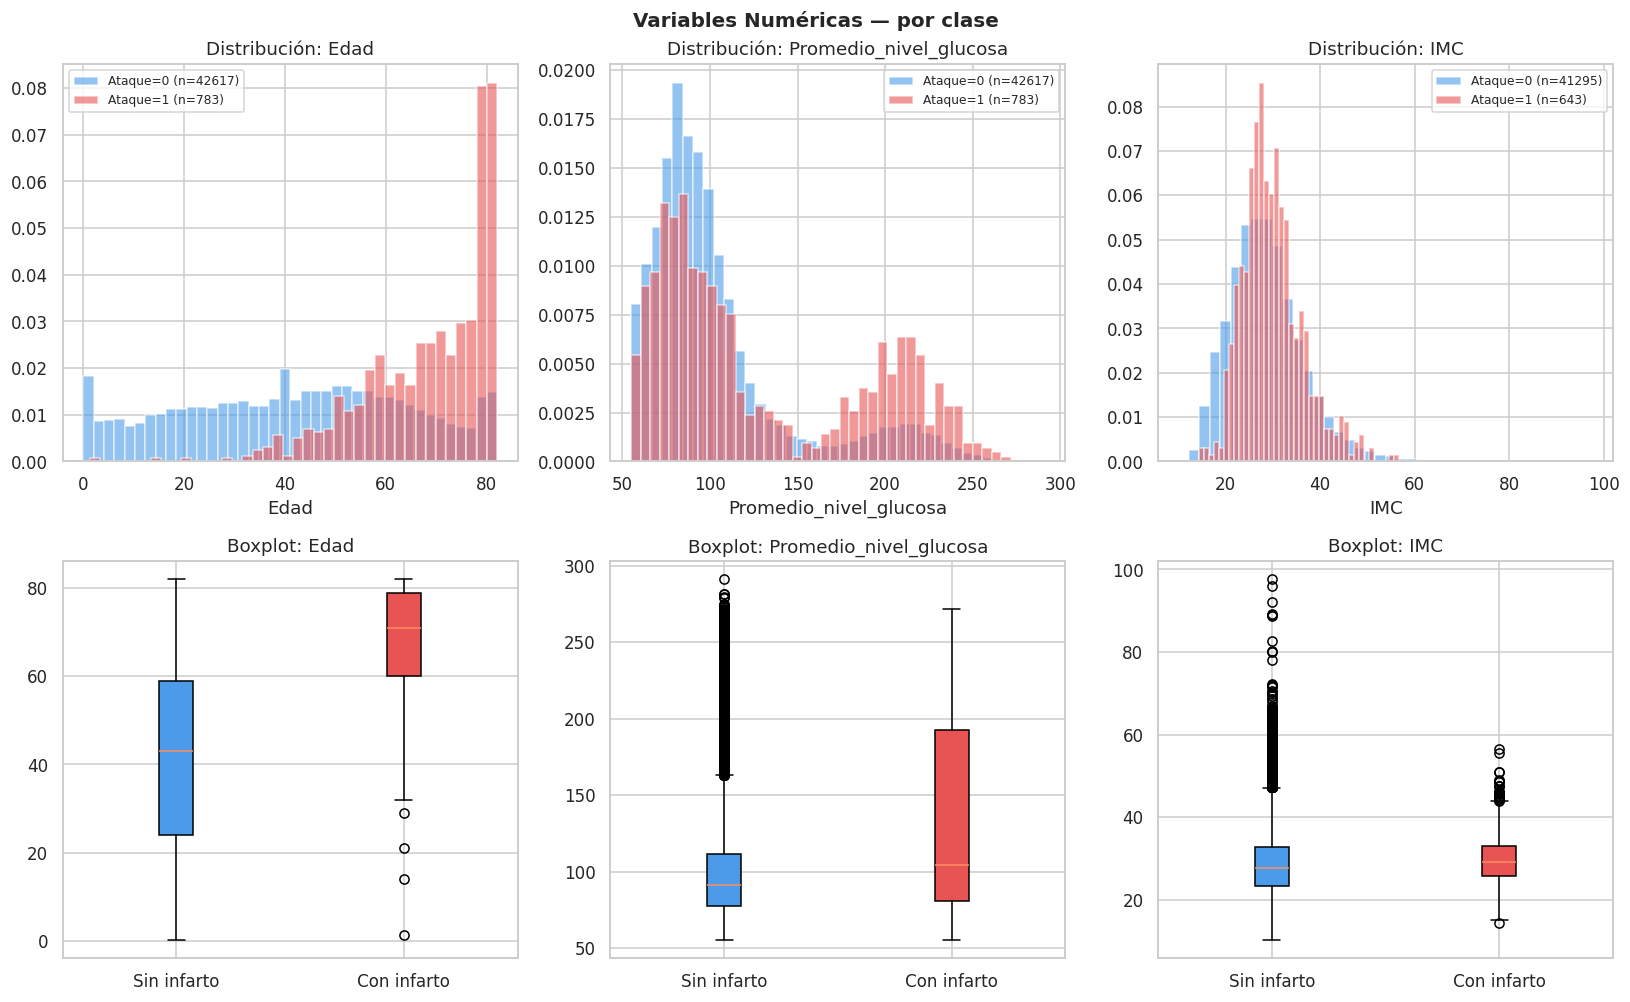

In [9]:
cols_num = ['Edad', 'Promedio_nivel_glucosa', 'IMC']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, col in enumerate(cols_num):
    ax = axes[0, i]
    for label, color in [(0, '#4C9BE8'), (1, '#E85454')]:
        datos = df_raw[df_raw[TARGET] == label][col].dropna()
        ax.hist(datos, bins=40, alpha=0.6, color=color,
                label=f'Ataque={label} (n={len(datos)})', density=True)
    ax.set_title(f'Distribución: {col}')
    ax.set_xlabel(col)
    ax.legend(fontsize=8)

    ax2 = axes[1, i]
    data_plot = [df_raw[df_raw[TARGET] == lbl][col].dropna().values for lbl in [0, 1]]
    bp = ax2.boxplot(data_plot, labels=['Sin infarto', 'Con infarto'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#4C9BE8')
    bp['boxes'][1].set_facecolor('#E85454')
    ax2.set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.suptitle('Variables Numéricas — por clase', y=1.01, fontsize=13, fontweight='bold')
plt.savefig('../reportes/dist_numericas.png', bbox_inches='tight')
plt.show()

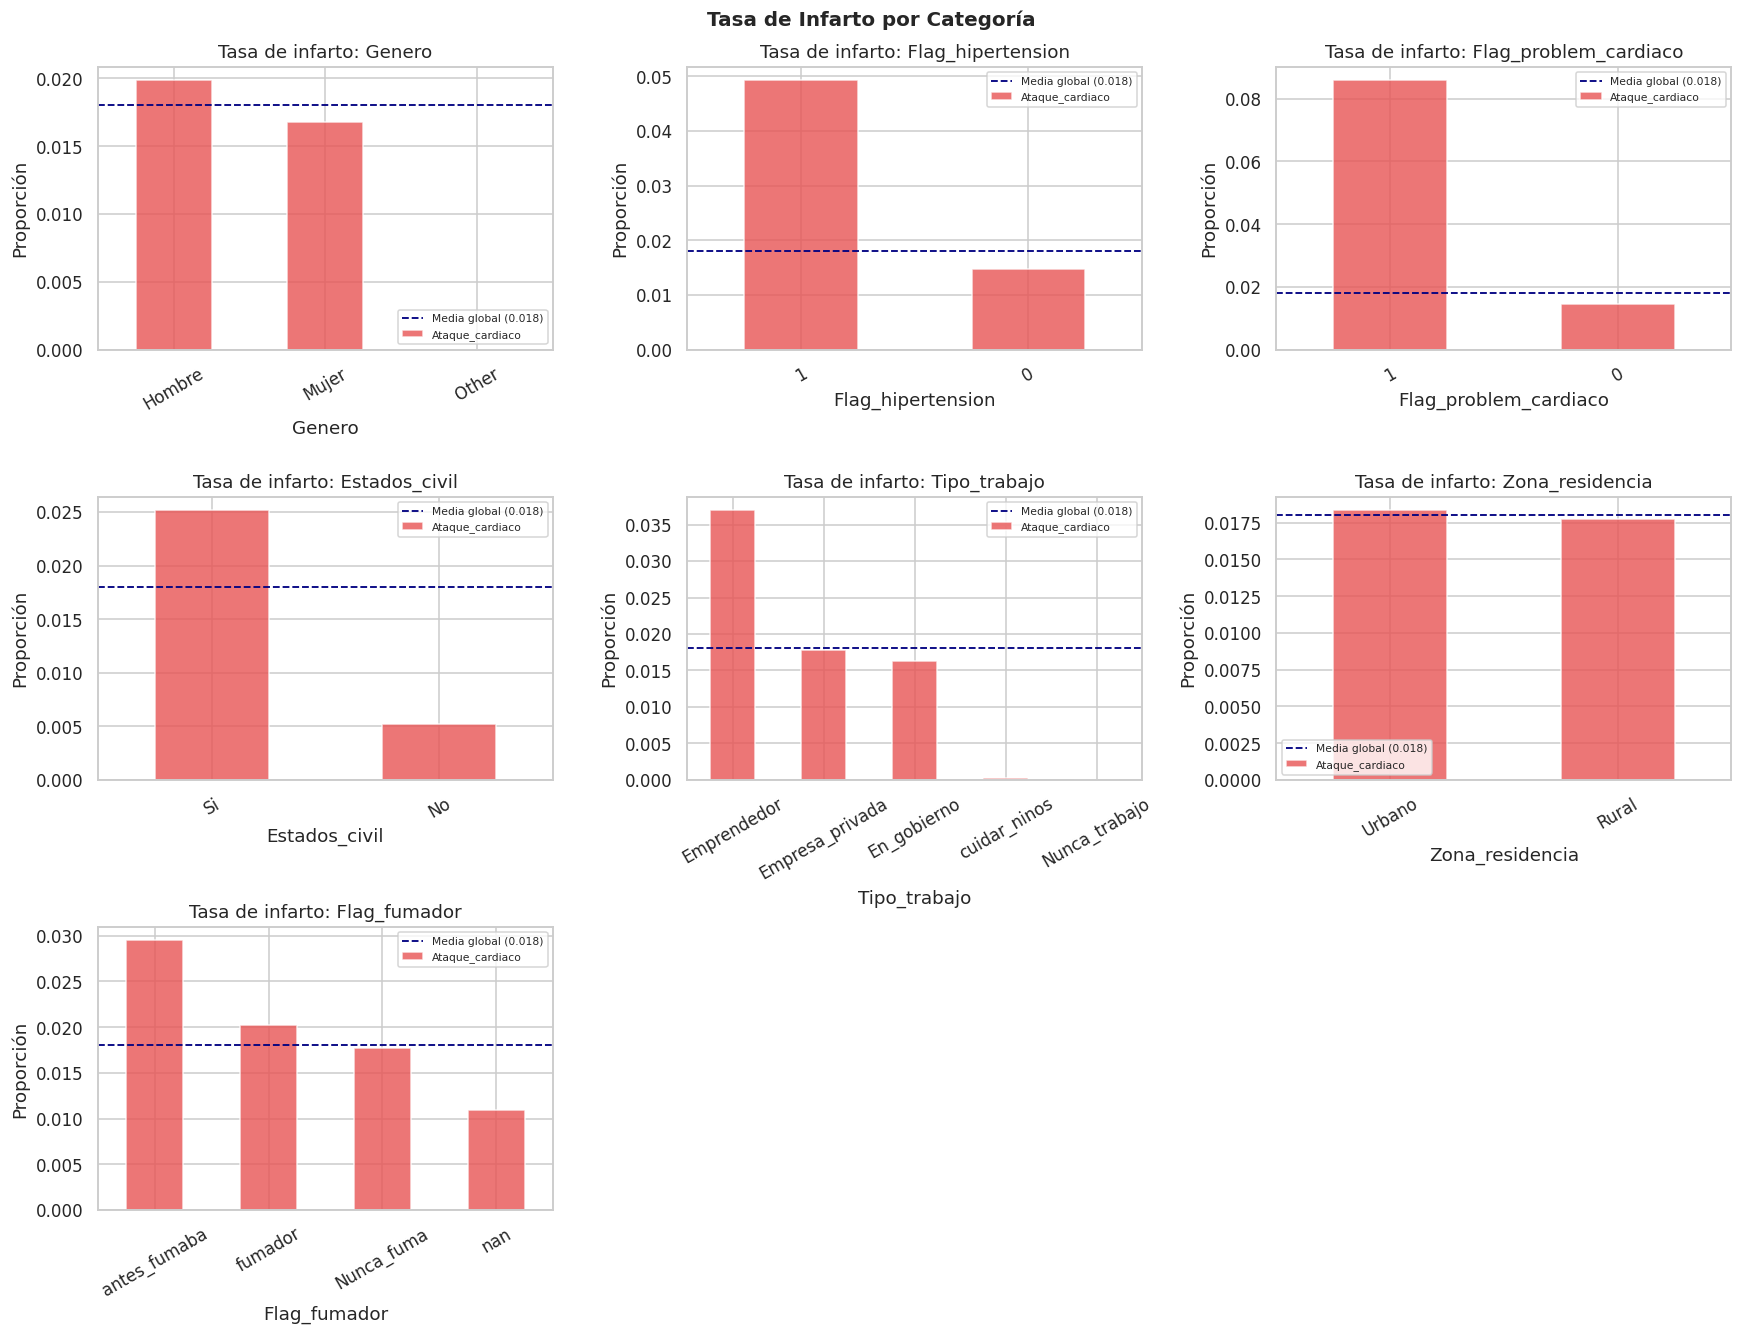

In [10]:
# Tasa de infarto por categoría (todas las categóricas)
cols_cat = ['Genero', 'Flag_hipertension', 'Flag_problem_cardiaco',
            'Estados_civil', 'Tipo_trabajo', 'Zona_residencia', 'Flag_fumador']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cols_cat):
    ax = axes[i]
    tasa = (
        df_raw.groupby(col, dropna=False)[TARGET]
        .mean()
        .sort_values(ascending=False)
    )
    tasa.plot(kind='bar', ax=ax, color='#E85454', alpha=0.8)
    ax.axhline(df_raw[TARGET].mean(), color='navy', linestyle='--',
               linewidth=1.2, label=f'Media global ({df_raw[TARGET].mean():.3f})')
    ax.set_title(f'Tasa de infarto: {col}')
    ax.set_ylabel('Proporción')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=7)

for j in range(len(cols_cat), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle('Tasa de Infarto por Categoría', y=1.01, fontsize=13, fontweight='bold')
plt.savefig('../reportes/dist_categoricas.png', bbox_inches='tight')
plt.show()

## 4 · Selección de características

Cuatro métodos estadísticos sobre el mismo conjunto de features. El **consenso** (ranking promedio entre los 4) reduce el riesgo de seleccionar una feature por un artefacto de un método concreto.

| Método | Supuesto | Fortaleza |
|---|---|---|
| Mann-Whitney U | No paramétrico | Robusto a outliers y distribuciones asimétricas |
| Correlación punto-biserial | Lineal | Interpretable directamente como correlación |
| ANOVA F (SelectKBest) | Normal aprox. | Método actual del pipeline — sirve como línea base |
| Información mutua | Ninguno | Captura relaciones no lineales y no monótonas |

In [11]:
df_fs = df_raw.copy()

with open(RUTA_DATASET, 'rb') as _f:
    DATA_HASH = hashlib.md5(_f.read()).hexdigest()
print(f'Dataset MD5: {DATA_HASH}')

# Genero='Other' — ningún infarto (sección 2) → descartar
n_other = (df_fs['Genero'] == 'Other').sum()
infartos_other = df_fs[df_fs['Genero'] == 'Other'][TARGET].sum()
if infartos_other == 0:
    df_fs = df_fs[df_fs['Genero'] != 'Other'].copy()

# Menores de 18 — solo 2 infartos en 7 541 filas (0.03 %) → excluir
N_MENORES_EXCLUIDOS = (df_fs['Edad'] < 18).sum()
df_fs = df_fs[df_fs['Edad'] >= 18].copy()

# IMC nulo — tasa de infarto mucho mayor que la global (9.6 % vs 1.8 %) → imputar, no descartar
IMC_MEDIANA = df_fs['IMC'].median()
df_fs['IMC'] = df_fs['IMC'].fillna(IMC_MEDIANA)

# Flag_fumador nulo — tasa ≈ global → categoría "Desconocido" (señal válida)
df_fs['Flag_fumador'] = df_fs['Flag_fumador'].fillna('Desconocido')

assert (df_fs['Edad'] == df_fs['Edad'].round()).all(), "Edad tiene decimales significativos"
df_fs['Edad'] = df_fs['Edad'].astype(int)

print(f'Dataset limpio: {df_fs.shape} | Nulos: {df_fs.isnull().sum().sum()}')
print(f'  Genero Other excluidos: {n_other} | Menores 18 excluidos: {N_MENORES_EXCLUIDOS}')
print(f'  IMC imputado con mediana={IMC_MEDIANA:.2f}')
print(f'  Zona_residencia excluida del encoding (no predictor cardiovascular)')

Dataset MD5: d6514153cd4ffc9791c36e3f05ebbbb3
Dataset limpio: (35850, 12) | Nulos: 0
  Genero Other excluidos: 11 | Menores 18 excluidos: 7539
  IMC imputado con mediana=29.10
  Zona_residencia excluida del encoding (no predictor cardiovascular)


In [12]:
# Zona_residencia excluida: no es predictor cardiovascular establecido
df_enc = df_fs.drop(columns=['ID', 'Zona_residencia'], errors='ignore').copy()

df_enc['Genero']        = df_enc['Genero'].map({'Hombre': 0, 'Mujer': 1}).fillna(0).astype(int)
df_enc['Estados_civil'] = df_enc['Estados_civil'].map({'No': 0, 'Si': 1}).fillna(0).astype(int)
df_enc = pd.get_dummies(df_enc, columns=['Tipo_trabajo', 'Flag_fumador'], drop_first=False, dtype=int)
df_enc = df_enc.select_dtypes(exclude=['object'])

X_all = df_enc.drop(columns=[TARGET])
y_all = df_enc[TARGET]
print(f'Features para análisis: {X_all.shape[1]} | Positivos: {y_all.sum()} ({y_all.mean()*100:.2f}%)')

# Separación train/test inicial para evitar fuga de datos (data leakage)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=RANDOM_STATE
)
print(f'Train set: {X_tr.shape[0]} filas | Test set: {X_te.shape[0]} filas')

Features para análisis: 15 | Positivos: 781 (2.18%)
Train set: 28680 filas | Test set: 7170 filas


In [13]:
# Mann-Whitney U — no asume distribución, compara rangos entre clases (calculado en Train)
mw_results = []
for col in X_tr.columns:
    stat, p = mannwhitneyu(X_tr[col][y_tr == 0], X_tr[col][y_tr == 1], alternative='two-sided')
    mw_results.append({'feature': col, 'MW_stat': stat, 'MW_pvalue': p})

df_mw = pd.DataFrame(mw_results).sort_values('MW_pvalue').reset_index(drop=True)
df_mw['MW_rank'] = range(1, len(df_mw) + 1)
df_mw.head(10)[['feature', 'MW_pvalue', 'MW_rank']]

,feature,MW_pvalue,MW_rank
0,Edad,1.068344e-155,1
1,Flag_problem_cardiaco,4.672972e-76,2
2,Flag_hipertension,1.468223e-33,3
3,Tipo_trabajo_Emprendedor,1.493952e-16,4
4,Promedio_nivel_glucosa,4.463549e-16,5
5,Estados_civil,4.157596e-14,6
6,Flag_fumador_antes_fumaba,5.817569e-08,7
7,Tipo_trabajo_Empresa_privada,1.913075e-06,8
8,Genero,3.258226e-03,9
9,Flag_fumador_Nunca_fuma,7.175692e-03,10


In [14]:
# Correlación punto-biserial — |r| entre cada feature y target (calculado en Train)
pb_results = []
for col in X_tr.columns:
    r, p = pointbiserialr(y_tr, X_tr[col])
    pb_results.append({'feature': col, 'PB_r': abs(r), 'PB_pvalue': p})

df_pb = pd.DataFrame(pb_results).sort_values('PB_r', ascending=False).reset_index(drop=True)
df_pb['PB_rank'] = range(1, len(df_pb) + 1)
df_pb.head(10)[['feature', 'PB_r', 'PB_rank']]

,feature,PB_r,PB_rank
0,Edad,0.160117,1
1,Flag_problem_cardiaco,0.108982,2
2,Promedio_nivel_glucosa,0.077320,3
3,Flag_hipertension,0.071290,4
4,Tipo_trabajo_Emprendedor,0.048757,5
5,Estados_civil,0.044618,6
6,Flag_fumador_antes_fumaba,0.032030,7
7,Tipo_trabajo_Empresa_privada,0.028122,8
8,Genero,0.017374,9
9,Flag_fumador_Nunca_fuma,0.015876,10


In [15]:
# ANOVA F — método actual del pipeline (SelectKBest con f_classif en Train)
selector_f = SelectKBest(f_classif, k='all')
selector_f.fit(X_tr, y_tr)
df_anova = pd.DataFrame({
    'feature': X_tr.columns, 'ANOVA_F': selector_f.scores_, 'ANOVA_pvalue': selector_f.pvalues_,
}).sort_values('ANOVA_F', ascending=False).reset_index(drop=True)
df_anova['ANOVA_rank'] = range(1, len(df_anova) + 1)
df_anova.head(10)[['feature', 'ANOVA_F', 'ANOVA_rank']]

,feature,ANOVA_F,ANOVA_rank
0,Edad,754.580258,1
1,Flag_problem_cardiaco,344.703562,2
2,Promedio_nivel_glucosa,172.479165,3
3,Flag_hipertension,146.495061,4
4,Tipo_trabajo_Emprendedor,68.337981,5
5,Estados_civil,57.204576,6
6,Flag_fumador_antes_fumaba,29.452473,7
7,Tipo_trabajo_Empresa_privada,22.697607,8
8,Genero,8.659243,9
9,Flag_fumador_Nunca_fuma,7.230041,10


In [16]:
# Información mutua — captura relaciones no lineales en Train
mi_scores = mutual_info_classif(X_tr, y_tr, random_state=RANDOM_STATE)
df_mi = pd.DataFrame({'feature': X_tr.columns, 'MI_score': mi_scores})
df_mi = df_mi.sort_values('MI_score', ascending=False).reset_index(drop=True)
df_mi['MI_rank'] = range(1, len(df_mi) + 1)
df_mi.head(10)[['feature', 'MI_score', 'MI_rank']]

,feature,MI_score,MI_rank
0,Edad,0.015588,1
1,Estados_civil,0.006513,2
2,Tipo_trabajo_Empresa_privada,0.005400,3
3,Genero,0.004499,4
4,Flag_problem_cardiaco,0.003449,5
5,Flag_fumador_Nunca_fuma,0.003404,6
6,Promedio_nivel_glucosa,0.002632,7
7,IMC,0.002254,8
8,Tipo_trabajo_Nunca_trabajo,0.002148,9
9,Tipo_trabajo_Emprendedor,0.001784,10


In [17]:
# Consenso: promedio de los 4 rankings — features con rank_promedio bajo son las más robustas
df_rank = (
    df_mw[['feature', 'MW_rank', 'MW_pvalue']]
    .merge(df_pb[['feature', 'PB_rank', 'PB_r']], on='feature')
    .merge(df_anova[['feature', 'ANOVA_rank', 'ANOVA_F']], on='feature')
    .merge(df_mi[['feature', 'MI_rank', 'MI_score']], on='feature')
)
df_rank['rank_promedio'] = df_rank[['MW_rank', 'PB_rank', 'ANOVA_rank', 'MI_rank']].mean(axis=1)
df_rank = df_rank.sort_values('rank_promedio').reset_index(drop=True)
df_rank[['feature', 'MW_rank', 'PB_rank', 'ANOVA_rank', 'MI_rank', 'rank_promedio']].head(15)

,feature,MW_rank,PB_rank,ANOVA_rank,MI_rank,rank_promedio
0,Edad,1,1,1,1,1.00
1,Flag_problem_cardiaco,2,2,2,5,2.75
2,Promedio_nivel_glucosa,5,3,3,7,4.50
3,Estados_civil,6,6,6,2,5.00
4,Tipo_trabajo_Emprendedor,4,5,5,10,6.00
5,Flag_hipertension,3,4,4,14,6.25
6,Tipo_trabajo_Empresa_privada,8,8,8,3,6.75
7,Genero,9,9,9,4,7.75
8,Flag_fumador_antes_fumaba,7,7,7,13,8.50
9,Flag_fumador_Nunca_fuma,10,10,10,6,9.00


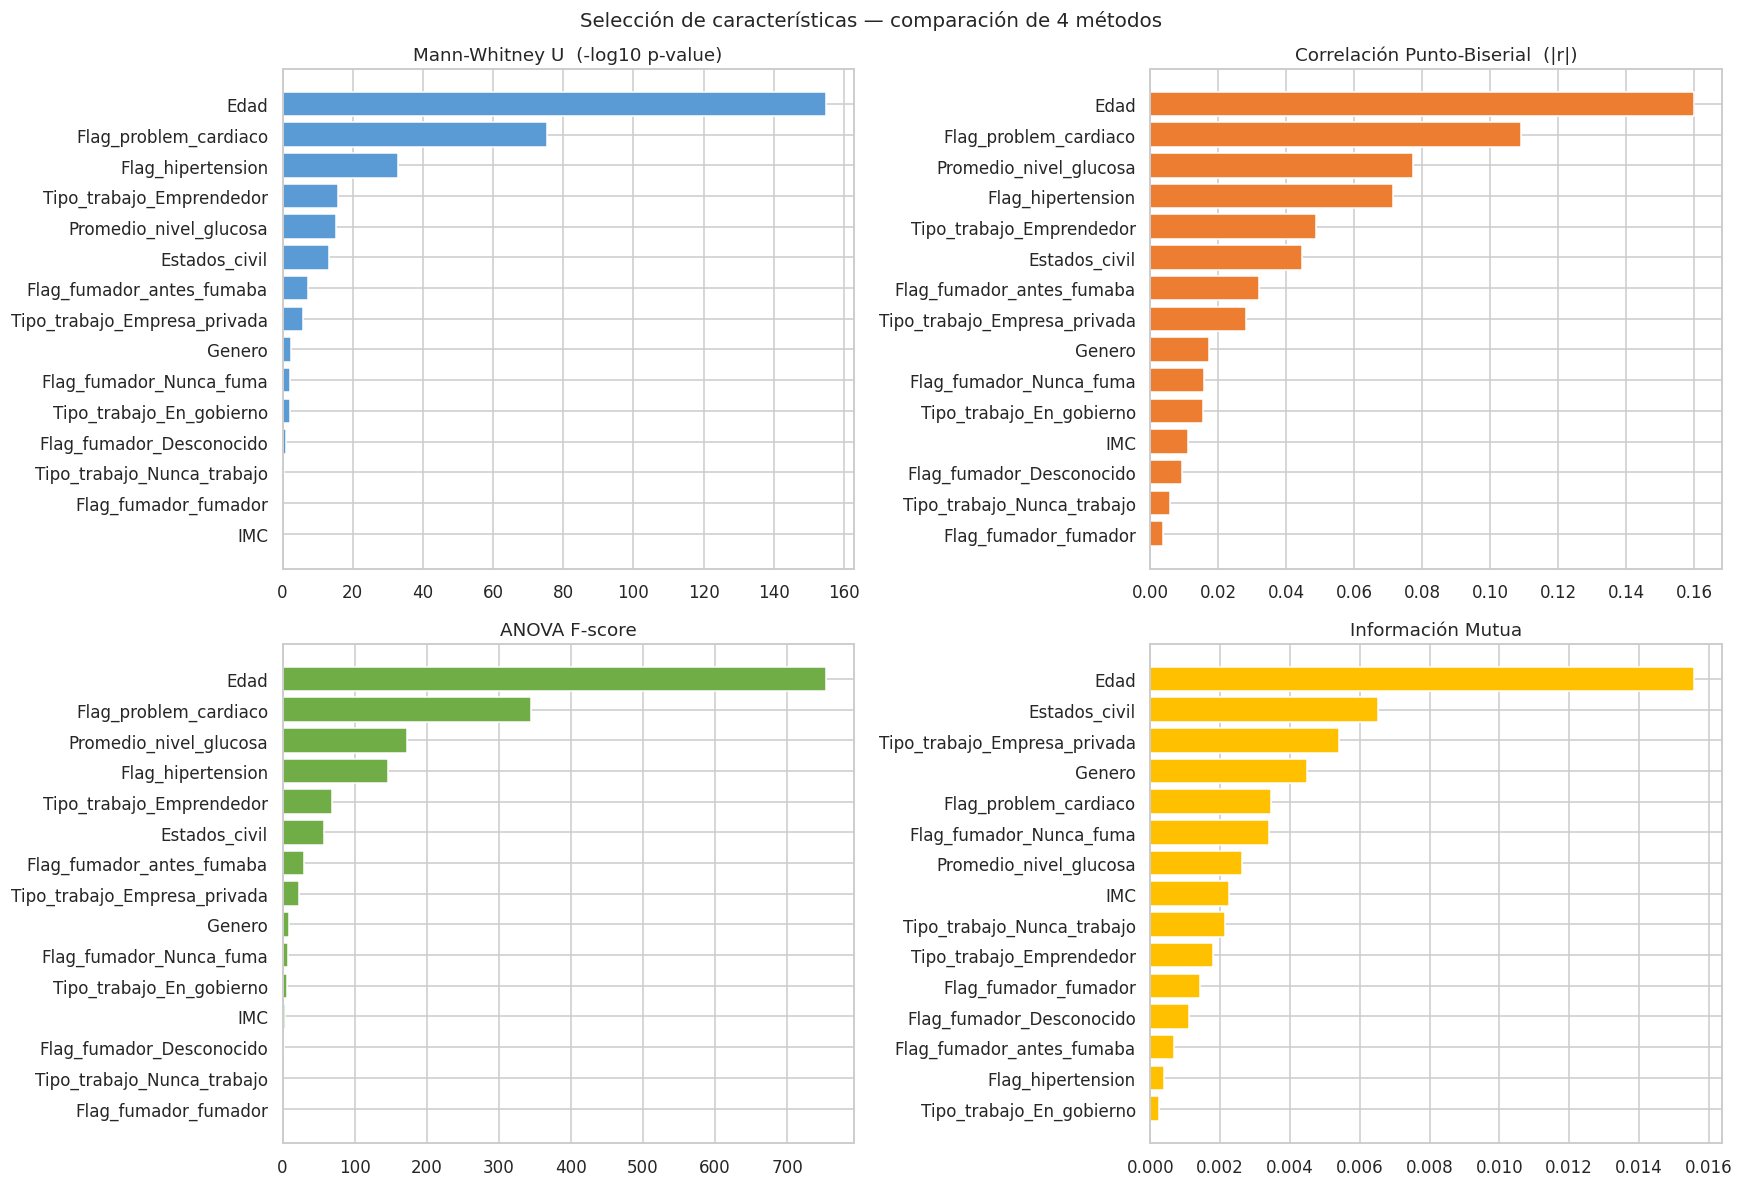

In [18]:
# Visualización comparativa — los 4 métodos (top 15)
top15 = df_rank.head(15)['feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sub = df_mw[df_mw['feature'].isin(top15)].sort_values('MW_pvalue')
axes[0, 0].barh(sub['feature'], -np.log10(sub['MW_pvalue'] + 1e-300), color='#5B9BD5')
axes[0, 0].set_title('Mann-Whitney U  (-log10 p-value)')
axes[0, 0].invert_yaxis()

sub = df_pb[df_pb['feature'].isin(top15)].sort_values('PB_r', ascending=False)
axes[0, 1].barh(sub['feature'], sub['PB_r'], color='#ED7D31')
axes[0, 1].set_title('Correlación Punto-Biserial  (|r|)')
axes[0, 1].invert_yaxis()

sub = df_anova[df_anova['feature'].isin(top15)].sort_values('ANOVA_F', ascending=False)
axes[1, 0].barh(sub['feature'], sub['ANOVA_F'], color='#70AD47')
axes[1, 0].set_title('ANOVA F-score')
axes[1, 0].invert_yaxis()

sub = df_mi[df_mi['feature'].isin(top15)].sort_values('MI_score', ascending=False)
axes[1, 1].barh(sub['feature'], sub['MI_score'], color='#FFC000')
axes[1, 1].set_title('Información Mutua')
axes[1, 1].invert_yaxis()

plt.suptitle('Selección de características — comparación de 4 métodos', fontsize=13)
plt.tight_layout()
plt.savefig('../reportes/feature_selection.png', bbox_inches='tight')
plt.show()

In [19]:
# Features con ≥ 3 votos de 4 métodos en el top-10 → consenso sólido
K = 10
top_mw = set(df_mw.head(K)['feature'])
top_pb = set(df_pb.head(K)['feature'])
top_an = set(df_anova.head(K)['feature'])
top_mi = set(df_mi.head(K)['feature'])

consenso = [{'feature': f, 'votos_top10': sum([f in top_mw, f in top_pb, f in top_an, f in top_mi])}
            for f in X_tr.columns]
df_consenso = pd.DataFrame(consenso).sort_values('votos_top10', ascending=False)
df_consenso[df_consenso['votos_top10'] >= 3]

,feature,votos_top10
0,Genero,4
1,Edad,4
3,Flag_problem_cardiaco,4
4,Estados_civil,4
5,Promedio_nivel_glucosa,4
7,Tipo_trabajo_Emprendedor,4
8,Tipo_trabajo_Empresa_privada,4
12,Flag_fumador_Nunca_fuma,4
2,Flag_hipertension,3
13,Flag_fumador_antes_fumaba,3


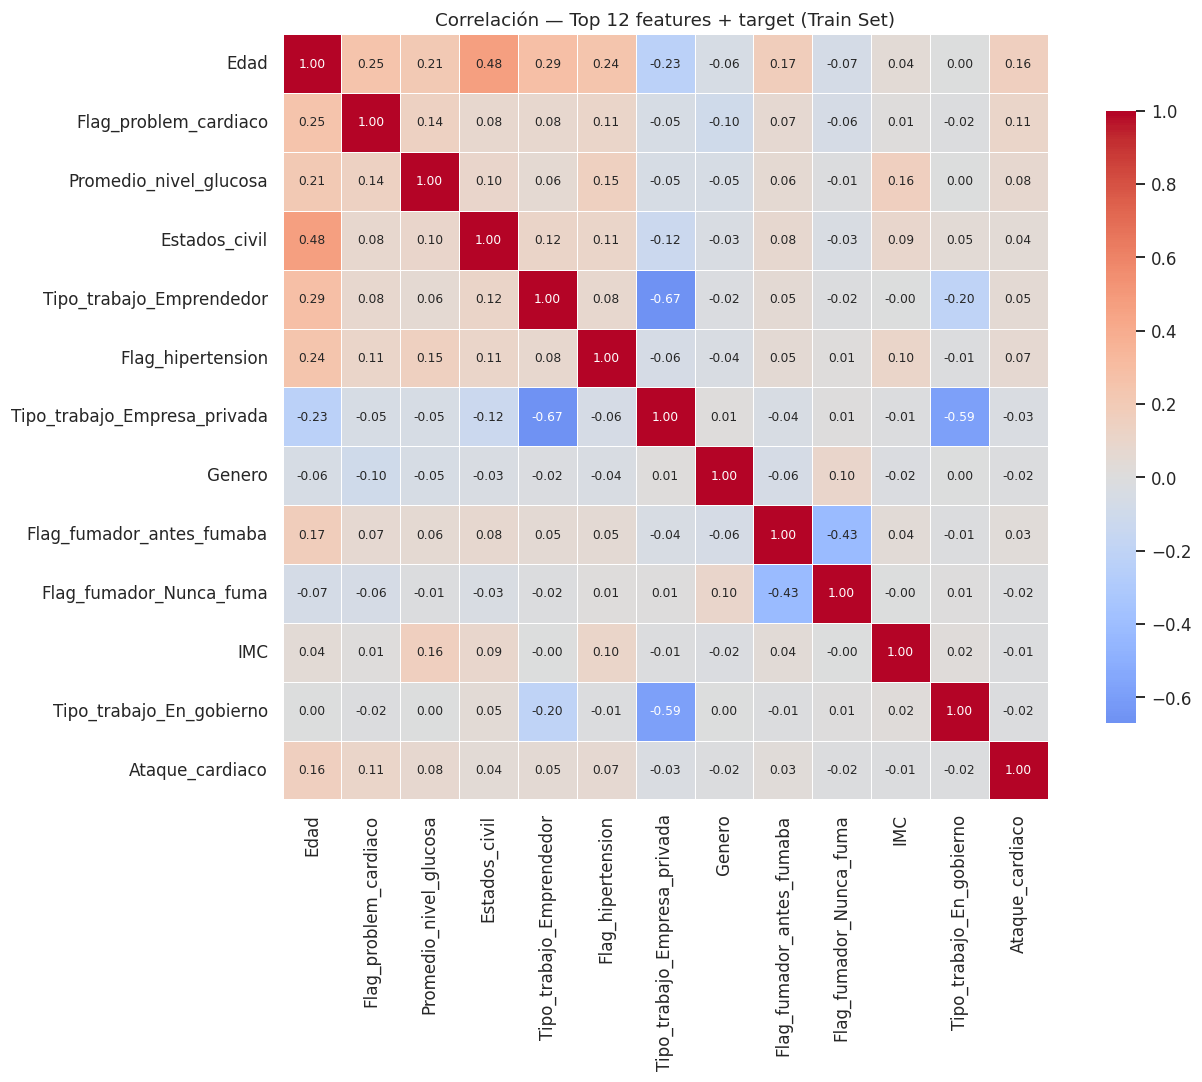

In [20]:
# Heatmap de correlación — top 12 features + target en Train
top12 = df_rank.head(12)['feature'].tolist()
df_corr = X_tr[top12].copy()
df_corr[TARGET] = y_tr

plt.figure(figsize=(13, 10))
sns.heatmap(
    df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}, annot_kws={'size': 8},
)
plt.title('Correlación — Top 12 features + target (Train Set)', fontsize=12)
plt.tight_layout()
plt.savefig('../reportes/heatmap_correlacion.png', bbox_inches='tight')
plt.show()

## 5 · Experimentos de modelos

Validación cruzada estratificada **10-fold** con Pipelines de sklearn/imblearn.

El escalado (`StandardScaler`) y el sobremuestreo (`SMOTE`) quedan **encapsulados dentro de cada fold** del CV, eliminando data leakage del scaler global.

**Métrica principal: Recall** — en diagnóstico cardíaco es peor perder un infarto real que generar una falsa alarma.
**Métricas de apoyo:** F1, MCC (robusto al desbalance extremo), PR-AUC.

In [21]:
N_FEATURES = 10
features_sel = df_rank.head(N_FEATURES)['feature'].tolist()
X_tr_sel = X_tr[features_sel].copy()
X_te_sel = X_te[features_sel].copy()
# El escalado ocurre dentro de cada Pipeline — sin data leakage
print(f'Top-{N_FEATURES} features seleccionadas (rank promedio):')
for i, f in enumerate(features_sel, 1):
    print(f'  {i:2d}. {f}')

Top-10 features seleccionadas (rank promedio):
   1. Edad
   2. Flag_problem_cardiaco
   3. Promedio_nivel_glucosa
   4. Estados_civil
   5. Tipo_trabajo_Emprendedor
   6. Flag_hipertension
   7. Tipo_trabajo_Empresa_privada
   8. Genero
   9. Flag_fumador_antes_fumaba
  10. Flag_fumador_Nunca_fuma


### Infraestructura de evaluación: CV en paralelo con Pipelines

Cada fold se ejecuta en un proceso independiente (`joblib.Parallel`). El `Pipeline` encapsula `StandardScaler → (SMOTE) → modelo` para que el escalado y el sobremuestreo aprendan **solo** sobre datos de entrenamiento de ese fold, eliminando data leakage.

In [22]:
from joblib import Parallel, delayed


def _entrenar_fold(pipeline, X_tr, y_tr, X_te, y_te):
    """Un fold de CV — Pipeline maneja scaler + SMOTE internamente."""
    pipeline = copy.deepcopy(pipeline)
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    y_prob = (pipeline.predict_proba(X_te)[:, 1]
              if hasattr(pipeline, 'predict_proba') else None)
    return y_pred, y_te.values, y_prob


def evaluar_modelo(nombre, pipeline, X, y, n_splits=N_SPLITS):
    """CV estratificada 10-fold sin data leakage (scaler/SMOTE en Pipeline)."""
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    splits = [
        (X.iloc[ti].copy(), y.iloc[ti].copy(),
         X.iloc[vi].copy(), y.iloc[vi].copy())
        for ti, vi in cv.split(X, y)
    ]

    resultados = Parallel(n_jobs=-1, prefer='processes')(
        delayed(_entrenar_fold)(pipeline, Xtr, ytr, Xte, yte)
        for Xtr, ytr, Xte, yte in splits
    )

    recalls, f1s, mccs, bal_accs, praucs, precs = [], [], [], [], [], []
    for y_pred, y_te_val, y_prob in resultados:
        recalls.append(recall_score(y_te_val, y_pred, zero_division=0))
        f1s.append(f1_score(y_te_val, y_pred, zero_division=0, average='binary'))
        precs.append(precision_score(y_te_val, y_pred, zero_division=0, average='binary'))
        mccs.append(matthews_corrcoef(y_te_val, y_pred))
        bal_accs.append(balanced_accuracy_score(y_te_val, y_pred))
        if y_prob is not None:
            praucs.append(average_precision_score(y_te_val, y_prob))

    return {
        'modelo':       nombre,
        'recall_mean':  round(np.mean(recalls),   4),
        'recall_std':   round(np.std(recalls),    4),
        'f1_mean':      round(np.mean(f1s),       4),
        'f1_std':       round(np.std(f1s),        4),
        'mcc_mean':     round(np.mean(mccs),      4),
        'bal_acc_mean': round(np.mean(bal_accs),  4),
        'prauc_mean':   round(np.mean(praucs),    4) if praucs  else np.nan,
        'precision_mean': round(np.mean(precs),   4),
    }

### Modelos candidatos — sin SMOTE, maximizando F1

Tres estrategias que manejan el desbalance **sin SMOTE** (sin distorsión de priors en producción).

| Modelo | Mecanismo anti-desbalance | Ventaja |
|--------|--------------------------|--------|
| `LR_balanced` | `class_weight='balanced'` | Lineal, interpretable, priors reales |
| `RF_balanced` | `class_weight='balanced'` | Ensemble, captura relaciones no lineales |
| `GaussianNB_cal` | Calibración isotónica | Probabilidades dispersas en [0,1] → threshold ajustable |

La métrica principal es **F1** (media armónica de Precision y Recall). Con solo 2.18 % de positivos, un Recall alto sin Precision adecuada genera alertas inmanejables — F1 penaliza ambos extremos.

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import GaussianNB

modelos_cfg = {
    'LR_balanced': (Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LogisticRegression(
            class_weight='balanced', C=0.1, max_iter=1000, random_state=RANDOM_STATE)),
    ]), None),
    'RF_balanced': (Pipeline([
        ('scaler', StandardScaler()),
        ('model',  RandomForestClassifier(
            class_weight='balanced', n_estimators=200, max_depth=10,
            random_state=RANDOM_STATE, n_jobs=-1)),
    ]), None),
    'GaussianNB_cal': (Pipeline([
        ('scaler', StandardScaler()),
        ('model',  CalibratedClassifierCV(GaussianNB(), method='isotonic', cv=5)),
    ]), None),
}


In [24]:
import time

resultados_modelos = []
for nombre, (pipeline, _) in modelos_cfg.items():
    t0 = time.time()
    print(f'  {nombre}...', end=' ', flush=True)
    res = evaluar_modelo(nombre, pipeline, X_tr_sel, y_tr, N_SPLITS)
    resultados_modelos.append(res)
    t1 = time.time()
    print(f'Recall={res["recall_mean"]:.4f}±{res["recall_std"]:.4f}  F1={res["f1_mean"]:.4f}  '
          f'MCC={res["mcc_mean"]:.4f}  [{t1-t0:.0f}s]')

# Orden: Recall (primario), F1 (desempate / freno a Precision baja)
df_modelos = (pd.DataFrame(resultados_modelos)
              .sort_values(['recall_mean', 'f1_mean'], ascending=[False, False])
              .reset_index(drop=True))
print('\n=== Resultados (ordenados por Recall, desempate F1) ===')
display(df_modelos[['modelo', 'recall_mean', 'recall_std', 'f1_mean', 'mcc_mean', 'bal_acc_mean', 'prauc_mean']].round(4))

  LR_balanced... 

/home/rodolfo/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/rodolfo/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/home/rodolfo/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/rodolfo/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALL

/home/rodolfo/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/home/rodolfo/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/rodolfo/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/rodolfo/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/home/rodolfo/.local/lib/python3.10/si

Recall=0.7790±0.0424  F1=0.1090  MCC=0.1609  [2s]
  RF_balanced... 

/home/rodolfo/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/rodolfo/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/home/rodolfo/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/rodolfo/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/home/rodolfo/.local/lib/python3.10/si

/home/rodolfo/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/rodolfo/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


Recall=0.3473±0.0397  F1=0.1168  MCC=0.1152  [5s]
  GaussianNB_cal... 

Recall=0.0000±0.0000  F1=0.0000  MCC=0.0000  [1s]

=== Resultados (ordenados por Recall, desempate F1) ===


,modelo,recall_mean,recall_std,f1_mean,mcc_mean,bal_acc_mean,prauc_mean
0,LR_balanced,0.7790,0.0424,0.1090,0.1609,0.7499,0.0909
1,RF_balanced,0.3473,0.0397,0.1168,0.1152,0.6223,0.0712
2,GaussianNB_cal,0.0000,0.0000,0.0000,0.0000,0.5000,0.0735


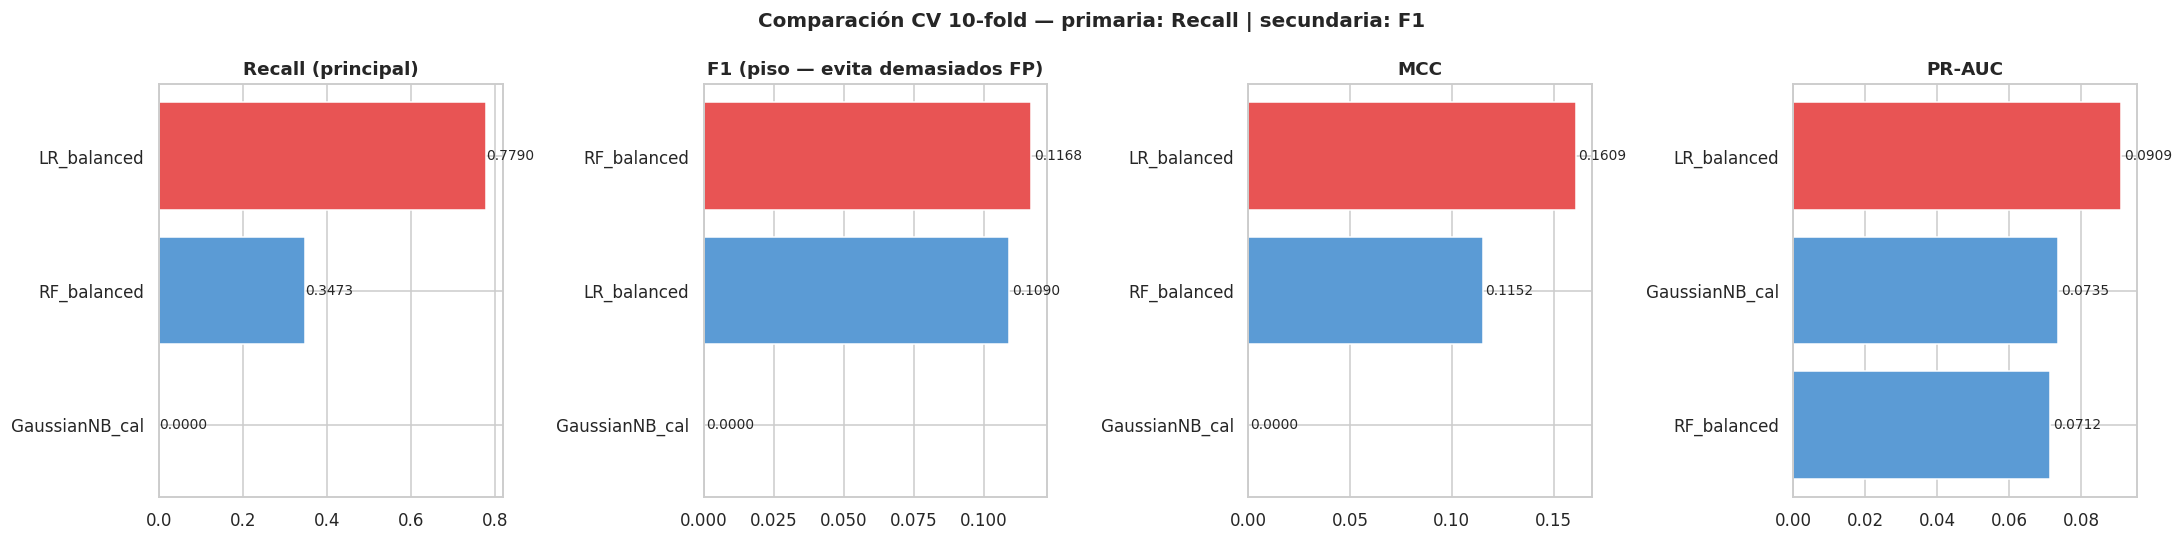

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics_plot = [
    ('recall_mean', 'Recall (principal)'),
    ('f1_mean',     'F1 (piso — evita demasiados FP)'),
    ('mcc_mean',    'MCC'),
    ('prauc_mean',  'PR-AUC'),
]
df_plot = df_modelos.set_index('modelo')

for ax, (col, label) in zip(axes, metrics_plot):
    vals = df_plot[col].sort_values(ascending=True)
    colors = ['#E85454' if v == vals.max() else '#5B9BD5' for v in vals]
    ax.barh(vals.index, vals.values, color=colors)
    ax.set_title(label, fontsize=12, fontweight='bold')
    for i, (idx, v) in enumerate(vals.items()):
        ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('Comparación CV 10-fold — primaria: Recall | secundaria: F1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reportes/comparacion_modelos.png', bbox_inches='tight')
plt.show()

## 6 · Búsqueda de hiperparámetros

`RandomizedSearchCV` con **`scoring='recall'`** (Recall binario sobre la clase positiva) y validación cruzada estratificada 10-fold. Se optimizan los 3 modelos sobre sus grillas de parámetros.

**Por qué Recall y no F1**: en salud cardiovascular un falso negativo (paciente con infarto futuro clasificado como sano) tiene costo clínico mucho mayor que un falso positivo (revisión innecesaria). El F1 se usa después como **piso** al elegir el threshold operativo — para evitar que el modelo prediga "todo positivo" y dispare los FP sin aportar señal.

Nota: `GaussianNB_cal` tiene pocos hiperparámetros (`method`, `cv` interno) porque la calibración isotónica no tiene muchos grados de libertad. La ganancia proviene de RF y LR.

In [26]:
top3_nombres = df_modelos['modelo'].tolist()
nombres_busqueda = top3_nombres
print(f'Modelos en búsqueda: {top3_nombres}')

grillas = {
    'LR_balanced': {
        'model__C':      [0.001, 0.01, 0.1, 0.5, 1, 5, 10],
        'model__solver': ['liblinear', 'saga'],
    },
    'RF_balanced': {
        'model__n_estimators':     [100, 200, 300],
        'model__max_depth':        [None, 5, 10, 20],
        'model__min_samples_leaf': [1, 5, 10],
    },
    'GaussianNB_cal': {
        'model__method': ['isotonic', 'sigmoid'],
        'model__cv':     [3, 5],
    },
}


Modelos en búsqueda: ['LR_balanced', 'RF_balanced', 'GaussianNB_cal']


In [27]:
cv_search = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
mejores_modelos = {}

for nombre in nombres_busqueda:
    if nombre not in grillas or nombre not in modelos_cfg:
        print(f'Sin grilla para {nombre}, usando pipeline base.')
        pipeline_base, _ = modelos_cfg[nombre]
        mejores_modelos[nombre] = (pipeline_base, None)
        continue

    pipeline_base, _ = modelos_cfg[nombre]
    n_combos = 1
    for v in grillas[nombre].values():
        n_combos *= len(v)
    n_iter = min(n_combos, 15)

    print(f'  {nombre}... (n_iter={n_iter})', end=' ', flush=True)
    search = RandomizedSearchCV(
        pipeline_base, grillas[nombre],
        n_iter=n_iter, scoring='recall',
        cv=cv_search, random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
    )
    search.fit(X_tr_sel, y_tr)
    print(f'Recall_CV={search.best_score_:.4f}  params={search.best_params_}')
    mejores_modelos[nombre] = (search.best_estimator_, search.best_params_)

  LR_balanced... (n_iter=14) 

Recall_CV=0.8078  params={'model__solver': 'liblinear', 'model__C': 0.001}
  RF_balanced... (n_iter=15) 

Recall_CV=0.7822  params={'model__n_estimators': 300, 'model__min_samples_leaf': 10, 'model__max_depth': 5}
  GaussianNB_cal... (n_iter=4) 

Recall_CV=0.0000  params={'model__method': 'isotonic', 'model__cv': 3}


In [28]:
resultados_tuned = []
for nombre, (pipeline_tuned, _) in mejores_modelos.items():
    print(f'  {nombre}...', end=' ', flush=True)
    res = evaluar_modelo(f'{nombre}_tuned', pipeline_tuned, X_tr_sel, y_tr, N_SPLITS)
    resultados_tuned.append(res)
    print(f'Recall={res["recall_mean"]:.4f}±{res["recall_std"]:.4f}  F1={res["f1_mean"]:.4f}')

df_tuned = (pd.DataFrame(resultados_tuned)
            .sort_values(['recall_mean', 'f1_mean'], ascending=[False, False])
            .reset_index(drop=True))
display(df_tuned[['modelo', 'recall_mean', 'recall_std', 'f1_mean', 'mcc_mean', 'bal_acc_mean', 'prauc_mean']].round(4))

  LR_balanced... 

Recall=0.8078±0.0497  F1=0.1032
  RF_balanced... 

Recall=0.7822±0.0419  F1=0.1097
  GaussianNB_cal... 

Recall=0.0000±0.0000  F1=0.0000


,modelo,recall_mean,recall_std,f1_mean,mcc_mean,bal_acc_mean,prauc_mean
0,LR_balanced_tuned,0.8078,0.0497,0.1032,0.1563,0.7494,0.0907
1,RF_balanced_tuned,0.7822,0.0419,0.1097,0.1624,0.7520,0.0905
2,GaussianNB_cal_tuned,0.0000,0.0000,0.0000,0.0000,0.5000,0.0744


In [29]:
df_comparacion = (pd.concat([df_modelos, df_tuned], ignore_index=True)
                  .sort_values(['recall_mean', 'f1_mean'], ascending=[False, False])
                  .reset_index(drop=True))
display(df_comparacion[['modelo', 'recall_mean', 'recall_std', 'f1_mean', 'mcc_mean', 'bal_acc_mean', 'prauc_mean']].round(4))

,modelo,recall_mean,recall_std,f1_mean,mcc_mean,bal_acc_mean,prauc_mean
0,LR_balanced_tuned,0.8078,0.0497,0.1032,0.1563,0.7494,0.0907
1,RF_balanced_tuned,0.7822,0.0419,0.1097,0.1624,0.7520,0.0905
2,LR_balanced,0.7790,0.0424,0.1090,0.1609,0.7499,0.0909
3,RF_balanced,0.3473,0.0397,0.1168,0.1152,0.6223,0.0712
4,GaussianNB_cal,0.0000,0.0000,0.0000,0.0000,0.5000,0.0735
5,GaussianNB_cal_tuned,0.0000,0.0000,0.0000,0.0000,0.5000,0.0744


## 7 · Selección y evaluación del mejor modelo

### ¿Qué tan grande es el test set? ¿Es necesario el CV?

**Tamaño del test set (20%):**
- Dataset limpio (adultos ≥18, sin 'Other'): **35,850 filas** | **781 positivos (2.18%)**
- Test set: **7,170 filas** con **~156 positivos** (~2.18%)

**¿Por qué el CV 10-fold sigue siendo necesario?**

Con solo ~156 positivos en el test set, la varianza del F1 es muy alta — un solo paciente cambia las métricas significativamente. El CV 10-fold evalúa **todos los 781 positivos** (~78 por fold × 10) y promedia, dando un estimador más robusto. El test set se usa solo para la **evaluación final definitiva**.

In [30]:
mejor_nombre = df_tuned.iloc[0]['modelo'].replace('_tuned', '')
mejor_pipeline_cv, _ = mejores_modelos[mejor_nombre]
print(f'Mejor modelo por Recall CV (desempate F1): {mejor_nombre}')
print(f'  Recall_CV = {df_tuned.iloc[0]["recall_mean"]:.4f} ± {df_tuned.iloc[0]["recall_std"]:.4f}')
print(f'  F1_CV     = {df_tuned.iloc[0]["f1_mean"]:.4f}')
print(f'  MCC_CV    = {df_tuned.iloc[0]["mcc_mean"]:.4f}')

# Nota: X_tr, X_te, y_tr, y_te ya fueron divididos al inicio para evitar data leakage.
# Entrenamos el mejor modelo final en X_tr_sel y evaluamos en X_te_sel.

mejor_pipeline_final = copy.deepcopy(mejor_pipeline_cv)
mejor_pipeline_final.fit(X_tr_sel, y_tr)
y_pred = mejor_pipeline_final.predict(X_te_sel)
y_prob_best = mejor_pipeline_final.predict_proba(X_te_sel)[:, 1]

print(f'\n=== Classification Report — {mejor_nombre} (threshold=0.5) ===')
print(classification_report(y_te, y_pred, target_names=['Sin infarto', 'Con infarto']))

mcc_val = matthews_corrcoef(y_te, y_pred)
bal_acc = balanced_accuracy_score(y_te, y_pred)
pr_auc  = average_precision_score(y_te, y_prob_best)
print(f'MCC: {mcc_val:.4f} | Balanced Accuracy: {bal_acc:.4f} | PR-AUC: {pr_auc:.4f}')

Mejor modelo por Recall CV (desempate F1): LR_balanced
  Recall_CV = 0.8078 ± 0.0497
  F1_CV     = 0.1032
  MCC_CV    = 0.1563

=== Classification Report — LR_balanced (threshold=0.5) ===
              precision    recall  f1-score   support

 Sin infarto       0.99      0.70      0.82      7014
 Con infarto       0.06      0.81      0.11       156

    accuracy                           0.70      7170
   macro avg       0.53      0.76      0.46      7170
weighted avg       0.97      0.70      0.80      7170

MCC: 0.1610 | Balanced Accuracy: 0.7560 | PR-AUC: 0.0864


### Ajuste de threshold — maximizando Recall con piso de F1

El threshold por defecto (0.5) no es el óptimo en datos desbalanceados. Para cada modelo buscamos el threshold que **maximiza Recall** con la restricción de que **F1 ≥ piso** (evita que el modelo prediga "todo positivo" y dispare los FP).

- Al **bajar el threshold**: más positivos predichos → Recall ↑, Precision ↓ → F1 cae si baja mucho
- El **piso de F1** garantiza que el modelo elegido sigue aportando señal — no es solo un "detector" trivial
- Se reporta también el threshold sin restricción (max Recall puro) y el threshold que maximiza F1, para comparar

Se grafican las curvas Precision-Recall y Recall vs threshold para los 3 modelos, con un punto marcando el threshold operativo elegido.

Piso de F1 = 0.1

Modelo             | Thr_def    Rec     F1 | Thr_F1max    Rec     F1 |  Thr_op   Rec*    F1*  Alert%
------------------------------------------------------------------------------------------------


LR_balanced        |   0.500  0.814 0.1057 |     0.680  0.545 0.1463 |   0.485  0.821 0.1017   32.9%


RF_balanced        |   0.500  0.795 0.1119 |     0.645  0.571 0.1438 |   0.470  0.814 0.1006   33.0%


GaussianNB_cal     |   0.500  0.000 0.0000 |     0.060  0.295 0.1301 |   0.050  0.321 0.1235    9.1%

* = threshold operativo: max Recall sujeto a F1 >= piso


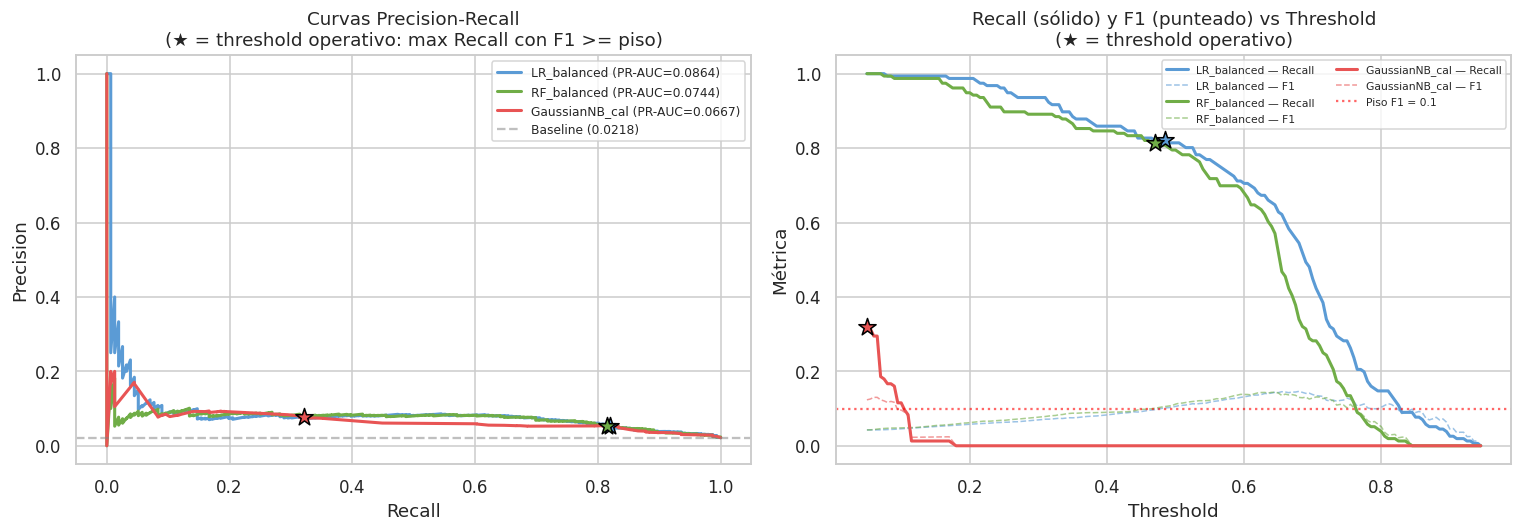

In [31]:
# Entrenar los 3 modelos en X_tr_sel, evaluar en X_te_sel
modelos_eval = {}
for nombre, (pipeline_cv, _) in mejores_modelos.items():
    p = copy.deepcopy(pipeline_cv)
    p.fit(X_tr_sel, y_tr)
    modelos_eval[nombre] = p.predict_proba(X_te_sel)[:, 1]

# Piso de F1 absoluto: evita que el threshold óptimo sea "todo positivo".
# Calibrado al F1 razonable observable en estos modelos (~0.10 con threshold default).
F1_FLOOR = 0.10

def optimal_recall_with_f1_floor(probs, y_true, f1_floor=F1_FLOOR,
                                  start=0.05, end=0.95, step=0.005):
    """
    Threshold que MAXIMIZA Recall sujeto a F1 >= f1_floor.
    Devuelve (thr, recall, f1). Si ningún threshold cumple el piso, devuelve el de máximo F1.
    """
    candidatos = []
    for t in np.arange(start, end, step):
        y_hat = (probs >= t).astype(int)
        f1v   = f1_score(y_true, y_hat, zero_division=0)
        rec   = recall_score(y_true, y_hat, zero_division=0)
        if f1v >= f1_floor:
            candidatos.append((t, rec, f1v))
    if candidatos:
        # max Recall; desempate por F1 mayor
        candidatos.sort(key=lambda x: (x[1], x[2]), reverse=True)
        t, r, f = candidatos[0]
        return round(t, 3), round(r, 4), round(f, 4)
    # fallback: max F1 puro
    best = (0.5, 0.0, 0.0)
    for t in np.arange(start, end, step):
        y_hat = (probs >= t).astype(int)
        f1v   = f1_score(y_true, y_hat, zero_division=0)
        rec   = recall_score(y_true, y_hat, zero_division=0)
        if f1v > best[2]:
            best = (t, rec, f1v)
    return round(best[0], 3), round(best[1], 4), round(best[2], 4)

def optimal_f1_threshold(probs, y_true, start=0.05, end=0.95, step=0.005):
    """Threshold que maximiza F1 — referencia comparativa."""
    best_t, best_f, best_r = 0.5, 0.0, 0.0
    for t in np.arange(start, end, step):
        y_hat = (probs >= t).astype(int)
        f = f1_score(y_true, y_hat, zero_division=0)
        if f > best_f:
            best_f, best_t = f, t
            best_r = recall_score(y_true, y_hat, zero_division=0)
    return round(best_t, 3), round(best_f, 4), round(best_r, 4)

print(f'Piso de F1 = {F1_FLOOR}\n')
print(f'{"Modelo":<18} | {"Thr_def":>7} {"Rec":>6} {"F1":>6} | '
      f'{"Thr_F1max":>9} {"Rec":>6} {"F1":>6} | '
      f'{"Thr_op":>7} {"Rec*":>6} {"F1*":>6} {"Alert%":>7}')
print('-' * 96)

thresholds_op = {}      # threshold operativo (max Recall con piso F1)
thresholds_f1max = {}   # referencia: max F1 puro
colors_mod = {'LR_balanced': '#5B9BD5', 'RF_balanced': '#70AD47', 'GaussianNB_cal': '#E85454'}

for nombre, probs in modelos_eval.items():
    y_def  = (probs >= 0.5).astype(int)
    f1_def = f1_score(y_te, y_def, zero_division=0)
    r_def  = recall_score(y_te, y_def, zero_division=0)

    thr_f1, f1_f1, r_f1 = optimal_f1_threshold(probs, y_te)
    thr_op, r_op, f1_op = optimal_recall_with_f1_floor(probs, y_te)
    y_op = (probs >= thr_op).astype(int)
    alertas_pct = y_op.sum() / len(y_te) * 100

    thresholds_op[nombre]    = (thr_op, f1_op, r_op)
    thresholds_f1max[nombre] = (thr_f1, f1_f1, r_f1)

    print(f'{nombre:<18} | {0.5:>7.3f} {r_def:>6.3f} {f1_def:>6.4f} | '
          f'{thr_f1:>9.3f} {r_f1:>6.3f} {f1_f1:>6.4f} | '
          f'{thr_op:>7.3f} {r_op:>6.3f} {f1_op:>6.4f} {alertas_pct:>6.1f}%')

print('\n* = threshold operativo: max Recall sujeto a F1 >= piso')

# ── Curvas PR y Recall vs threshold ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nombre, probs in modelos_eval.items():
    col = colors_mod.get(nombre, 'gray')
    prec_c, rec_c, _ = precision_recall_curve(y_te, probs)
    pr_auc_m = average_precision_score(y_te, probs)
    axes[0].plot(rec_c, prec_c, color=col, linewidth=2,
                 label=f'{nombre} (PR-AUC={pr_auc_m:.4f})')
    thr_op, _, _ = thresholds_op[nombre]
    y_op = (probs >= thr_op).astype(int)
    axes[0].scatter([recall_score(y_te, y_op, zero_division=0)],
                    [precision_score(y_te, y_op, zero_division=0)],
                    color=col, zorder=5, s=140, marker='*',
                    edgecolor='black', linewidth=1)

axes[0].axhline(y_te.mean(), color='gray', linestyle='--', alpha=0.5,
                label=f'Baseline ({y_te.mean():.4f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Curvas Precision-Recall\n(★ = threshold operativo: max Recall con F1 >= piso)')
axes[0].legend(fontsize=8)

thrs_range = np.arange(0.05, 0.95, 0.005)
for nombre, probs in modelos_eval.items():
    col = colors_mod.get(nombre, 'gray')
    recs = [recall_score(y_te, (probs >= t).astype(int), zero_division=0) for t in thrs_range]
    f1s  = [f1_score(y_te, (probs >= t).astype(int), zero_division=0) for t in thrs_range]
    axes[1].plot(thrs_range, recs, color=col, linewidth=2, label=f'{nombre} — Recall')
    axes[1].plot(thrs_range, f1s,  color=col, linewidth=1, linestyle='--', alpha=0.6,
                 label=f'{nombre} — F1')
    thr_op, f1_op, r_op = thresholds_op[nombre]
    axes[1].scatter([thr_op], [r_op], color=col, zorder=5, s=140, marker='*',
                    edgecolor='black', linewidth=1)

axes[1].axhline(F1_FLOOR, color='red', linestyle=':', alpha=0.6,
                label=f'Piso F1 = {F1_FLOOR}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Métrica')
axes[1].set_title('Recall (sólido) y F1 (punteado) vs Threshold\n(★ = threshold operativo)')
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('../reportes/pr_curves_recall_op.png', bbox_inches='tight')
plt.show()

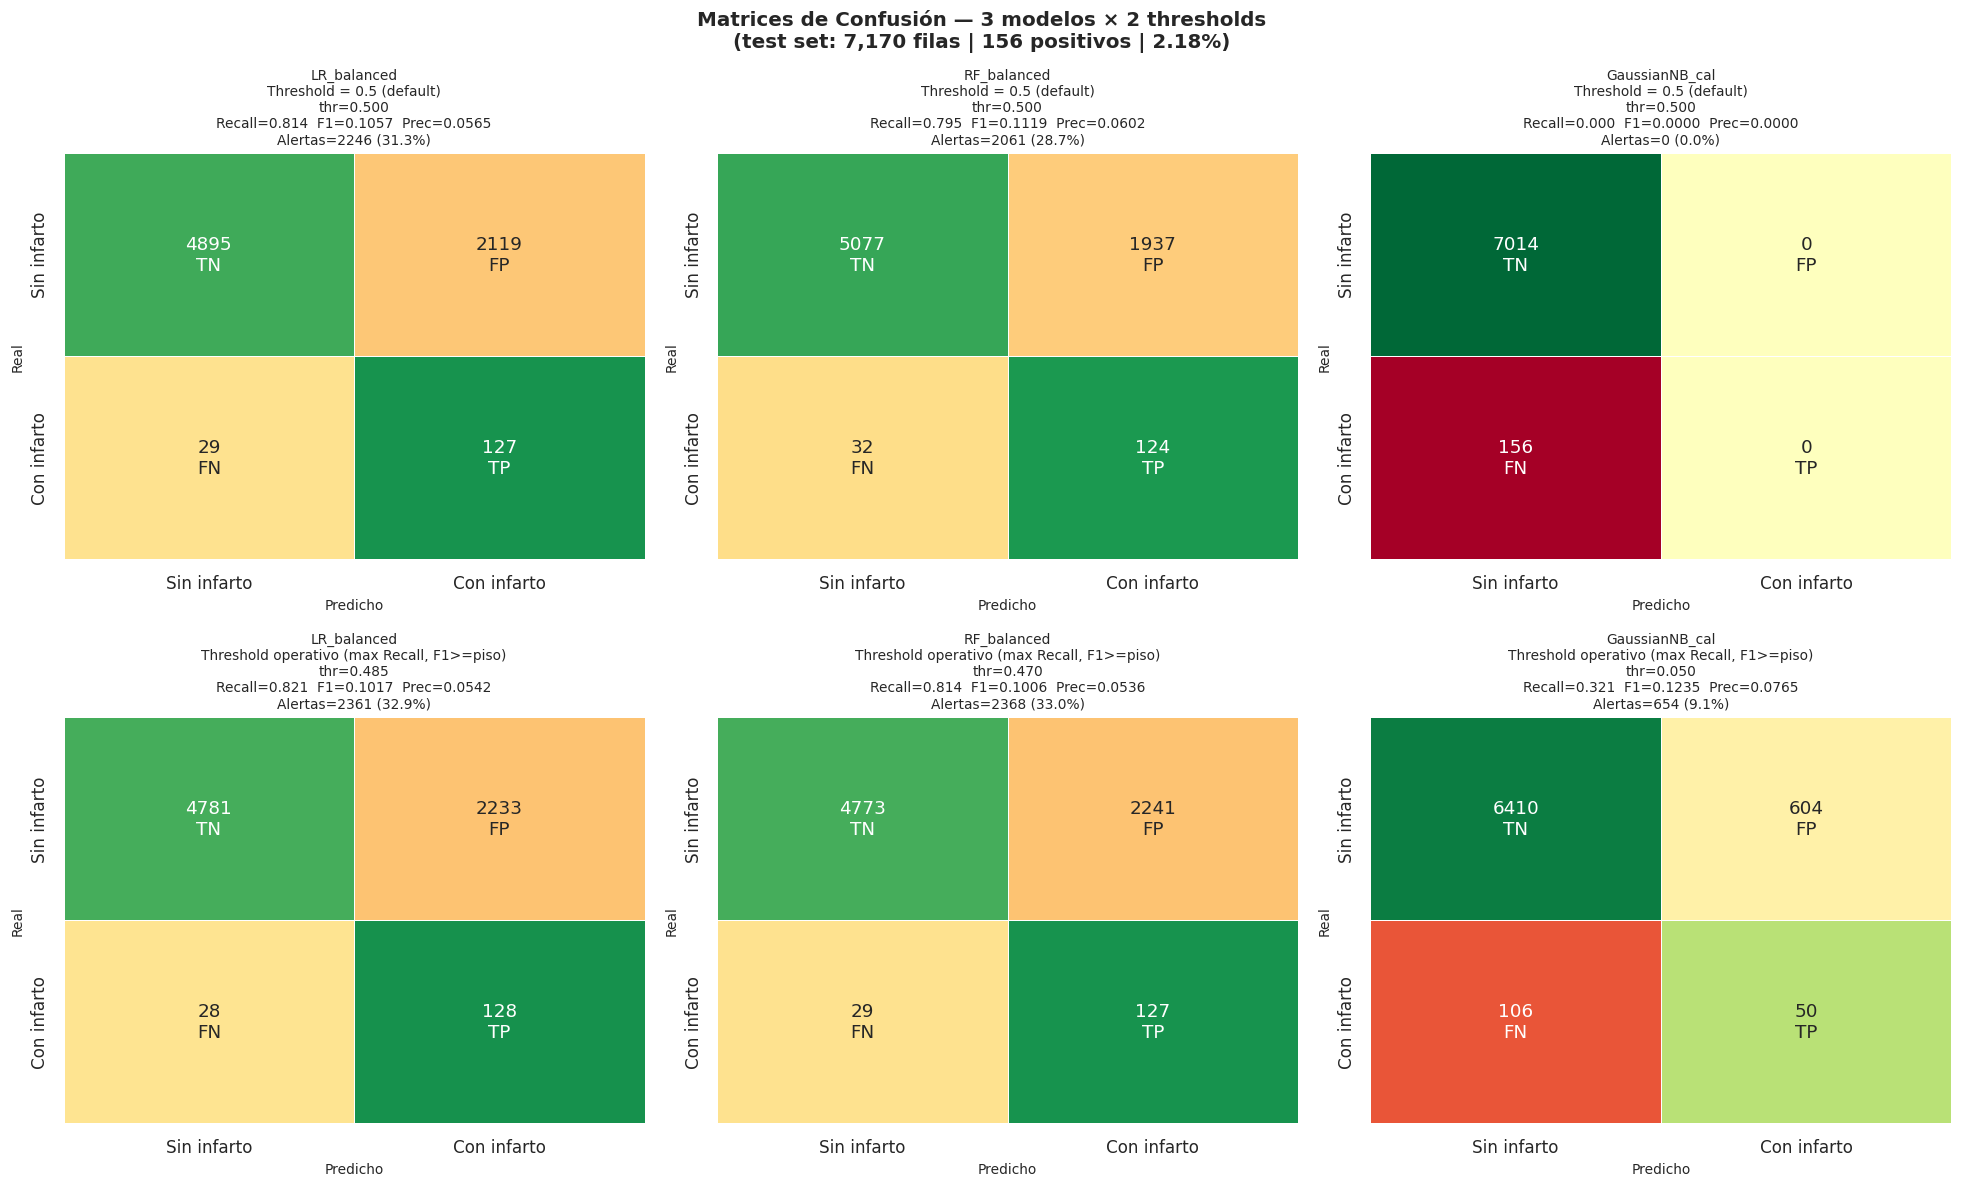

In [32]:
def plot_cm_ax(ax, cm, nombre, y_te_plot, y_pred_plot):
    f1v = f1_score(y_te_plot, y_pred_plot, zero_division=0)
    r   = recall_score(y_te_plot, y_pred_plot, zero_division=0)
    p   = precision_score(y_te_plot, y_pred_plot, zero_division=0)
    alertas = int(y_pred_plot.sum())
    cm_norm   = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_signed = np.array([
        [ cm_norm[0, 0], -cm_norm[0, 1]],
        [-cm_norm[1, 0],  cm_norm[1, 1]],
    ])
    labels = np.array([
        [f'{cm[0,0]}\nTN', f'{cm[0,1]}\nFP'],
        [f'{cm[1,0]}\nFN', f'{cm[1,1]}\nTP'],
    ])
    sns.heatmap(cm_signed, annot=labels, fmt='', cmap='RdYlGn',
                center=0, vmin=-1, vmax=1, ax=ax,
                xticklabels=['Sin infarto', 'Con infarto'],
                yticklabels=['Sin infarto', 'Con infarto'],
                cbar=False, linewidths=0.5)
    ax.set_xlabel('Predicho', fontsize=9)
    ax.set_ylabel('Real', fontsize=9)
    ax.set_title(
        f'{nombre}\nRecall={r:.3f}  F1={f1v:.4f}  Prec={p:.4f}\n'
        f'Alertas={alertas} ({alertas/len(y_te_plot)*100:.1f}%)',
        fontsize=9,
    )


etiq_thrs = ['Threshold = 0.5 (default)', 'Threshold operativo (max Recall, F1>=piso)']
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for col, (nombre, probs) in enumerate(modelos_eval.items()):
    thr_op, _, _ = thresholds_op[nombre]
    for row, (thr, etiq) in enumerate([(0.5, etiq_thrs[0]), (thr_op, etiq_thrs[1])]):
        ax = axes[row, col]
        y_pred_cm = (probs >= thr).astype(int)
        cm_i = confusion_matrix(y_te, y_pred_cm)
        plot_cm_ax(ax, cm_i, f'{nombre}\n{etiq}\nthr={thr:.3f}', y_te, y_pred_cm)

n_test   = len(y_te)
pos_test = int(y_te.sum())
plt.suptitle(
    f'Matrices de Confusión — 3 modelos × 2 thresholds\n'
    f'(test set: {n_test:,} filas | {pos_test} positivos | {pos_test/n_test*100:.2f}%)',
    fontsize=13, fontweight='bold',
)
plt.tight_layout()
plt.savefig('../reportes/cm_grid_modelos_thresholds.png', bbox_inches='tight')
plt.show()

## 8 · Resumen y recomendaciones para el pipeline

Síntesis de todas las decisiones del EDA que el pipeline de producción debe implementar.

In [33]:
print('=' * 65)
print('RESUMEN DE DECISIONES')
print('=' * 65)

print('\n── 1. LIMPIEZA Y FEATURE ENGINEERING ──────────────────────')
print(f'  Dataset MD5: {DATA_HASH}')
n_other_r   = (df_raw['Genero'] == 'Other').sum()
inf_other_r = df_raw[df_raw['Genero'] == 'Other'][TARGET].sum()
accion = 'DESCARTAR' if inf_other_r == 0 else 'MANTENER'
print(f"  Genero='Other': n={n_other_r}, infartos={inf_other_r} → {accion}")
print(f'  Menores de 18 excluidos: n={N_MENORES_EXCLUIDOS} (ruido clínico)')
print(f'  Zona_residencia: excluida (no es predictor cardiovascular establecido)')

print('\n── 2. FEATURES SELECCIONADAS ────────────────────────────────')
print(f'  Método: consenso de 4 métodos — top-{N_FEATURES} por rank promedio')
for i, row in df_rank.head(N_FEATURES).iterrows():
    votos = sum([
        row['feature'] in set(df_mw.head(10)['feature']),
        row['feature'] in set(df_pb.head(10)['feature']),
        row['feature'] in set(df_anova.head(10)['feature']),
        row['feature'] in set(df_mi.head(10)['feature']),
    ])
    print(f'  [{votos}/4] {row["feature"]}')

print('\n── 3. MÉTRICAS DE EVALUACIÓN ────────────────────────────────')
print('  Principal:   Recall — minimiza falsos negativos (alto costo clínico)')
print('  Secundaria:  F1 — piso operativo, evita modelo "todo positivo"')
print('  MCC:         Matthews Correlation Coefficient — robusta con desbalance')
print('  Bal. Acc.:   0.5*(sensibilidad + especificidad)')
print('  PR-AUC:      Precision-Recall AUC (baseline = prevalencia)')
print('  Eliminadas:  ROC-AUC (optimista con desbalance), accuracy (inútil)')

print('\n── 4. MODELOS (sin SMOTE, class_weight o calibración) ───────')
for nombre, (pipeline, _) in modelos_cfg.items():
    print(f'  {nombre}: {type(pipeline.steps[-1][1]).__name__}')
if resultados_tuned:
    mejor_r = df_tuned.iloc[0]
    print(f'  Mejor tuned → {mejor_r["modelo"]} | '
          f'Recall={mejor_r["recall_mean"]:.4f}±{mejor_r.get("recall_std", 0):.4f} | '
          f'F1={mejor_r["f1_mean"]:.4f} | MCC={mejor_r["mcc_mean"]:.4f}')
    if thresholds_op:
        mejor_base = mejor_r['modelo'].replace('_tuned', '')
        if mejor_base in thresholds_op:
            thr_op, f1_op, r_op = thresholds_op[mejor_base]
            print(f'  Threshold operativo (max Recall, F1>={F1_FLOOR}): '
                  f'{thr_op:.3f} → Recall={r_op:.4f}, F1={f1_op:.4f}')

print('\n── 5. PRÓXIMOS PASOS ────────────────────────────────────────')
print('  1. Actualizar src/preprocessing.py: excluir Edad<18 y Genero=Other ✓')
print('  2. Actualizar src/features.py: excluir Zona_residencia ✓')
print('  3. Actualizar src/train.py: LR_balanced + RF_balanced (scoring=recall, threshold óptimo)')
print('  4. Reentrenar: make train && make validate')

# ── MLflow: registrar resultados del EDA ─────────────────────────────────
if HAS_MLFLOW and resultados_tuned:
    try:
        mlflow.set_tracking_uri('../mlruns')
        mlflow.set_experiment('infartos-eda')
        with mlflow.start_run(run_name='eda_feature_selection_recall'):
            mlflow.log_param('dataset_hash',        DATA_HASH)
            mlflow.log_param('n_features',           N_FEATURES)
            mlflow.log_param('features_sel',         str(features_sel))
            mlflow.log_param('n_menores_excluidos',  N_MENORES_EXCLUIDOS)
            mlflow.log_param('cv_folds',             N_SPLITS)
            mlflow.log_param('scoring_cv',           'recall')
            mlflow.log_param('f1_floor',             F1_FLOOR)
            mlflow.log_param('mejor_modelo',         df_tuned.iloc[0]['modelo'])
            mlflow.log_metric('mejor_recall_cv', df_tuned.iloc[0]['recall_mean'])
            mlflow.log_metric('mejor_f1_cv',     df_tuned.iloc[0]['f1_mean'])
            mlflow.log_metric('mejor_mcc_cv',    df_tuned.iloc[0]['mcc_mean'])
        print('\nMLflow run registrado en infartos-eda.')
    except Exception as _e:
        print(f'\nMLflow: {_e}')

RESUMEN DE DECISIONES

── 1. LIMPIEZA Y FEATURE ENGINEERING ──────────────────────
  Dataset MD5: d6514153cd4ffc9791c36e3f05ebbbb3
  Genero='Other': n=11, infartos=0 → DESCARTAR
  Menores de 18 excluidos: n=7539 (ruido clínico)
  Zona_residencia: excluida (no es predictor cardiovascular establecido)

── 2. FEATURES SELECCIONADAS ────────────────────────────────
  Método: consenso de 4 métodos — top-10 por rank promedio
  [4/4] Edad
  [4/4] Flag_problem_cardiaco
  [4/4] Promedio_nivel_glucosa
  [4/4] Estados_civil
  [4/4] Tipo_trabajo_Emprendedor
  [3/4] Flag_hipertension
  [4/4] Tipo_trabajo_Empresa_privada
  [4/4] Genero
  [3/4] Flag_fumador_antes_fumaba
  [4/4] Flag_fumador_Nunca_fuma

── 3. MÉTRICAS DE EVALUACIÓN ────────────────────────────────
  Principal:   Recall — minimiza falsos negativos (alto costo clínico)
  Secundaria:  F1 — piso operativo, evita modelo "todo positivo"
  MCC:         Matthews Correlation Coefficient — robusta con desbalance
  Bal. Acc.:   0.5*(sensibilidad